# 🧪 SVM Student Lab
### Build your intuition — step by step, on real data

---

### 📌 What You Will Practise Today

| Concept | What it means in plain English |
|---|---|
| **Margin** | The gap between the two classes — SVM tries to make it as wide as possible |
| **Support Vectors** | The few training points that actually decide where the boundary goes |
| **C parameter** | How strict the model is. Small C = forgiving, large C = strict |
| **Kernels** | How the SVM draws its boundary — straight line, or curved |

### 🌍 Datasets We Use
| Dataset | What it is | Problem |
|---|---|---|
| **Breast Cancer** | 569 patients, 30 medical measurements | Is the tumour malignant or benign? |
| **Iris Flowers** | 150 flowers, 4 measurements | Which of 3 species is this flower? |
| **Digits** | 1797 handwritten digit images | Which digit 0–9 is this? |

### 📋 How to work through this
- Read each **Background** section carefully — the concept is explained there
- Then do the numbered steps in the code cell
- **💬 Think About It** boxes have questions — write your answers in the markdown cell
- Hidden solutions are available if you are stuck — but try first!

---

In [5]:
# ╔═══════════════════════════════════════╗
# ║  RUN THIS CELL FIRST — every time!   ║
# ╚═══════════════════════════════════════╝
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, accuracy_score
import warnings; warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Load all datasets
cancer = datasets.load_breast_cancer()
iris   = datasets.load_iris()
digits = datasets.load_digits()

print('✅ Ready to go!')
print(f'  Breast Cancer : {cancer.data.shape}')
print(f'  Iris          : {iris.data.shape}')
print(f'  Digits        : {digits.data.shape}')

✅ Ready to go!
  Breast Cancer : (569, 30)
  Iris          : (150, 4)
  Digits        : (1797, 64)


---
---
# 🏥 PART 1 — Breast Cancer
## "Can measurements of a tumour cell tell us if it is dangerous?"

Doctors take 30 measurements from each tumour cell (size, texture, smoothness, etc.)  
Your job: train an SVM to classify each tumour as **Malignant** (dangerous) or **Benign** (safe).

This is a real, life-or-death classification problem — which makes it perfect for building intuition about **what your model is actually doing**.

---

## ✏️ Task 1 — Look Before You Train

### Background
The first thing any data scientist does is **understand the data** before touching any model.  
Two things matter most:

1. **How many samples per class?** If 95% are benign and 5% malignant, a model that says "benign" every time would get 95% accuracy — but would miss every cancer case. This is called **class imbalance**.

2. **What do the features look like?** SVM uses distances between points. If one feature ranges from 0–1 and another from 0–10,000, the big one drowns out the small one. We fix this by **scaling**.

### Steps
1. Print: number of samples, number of features, class names
2. Print: how many samples per class
3. Make a **bar chart** — one bar per class, colour red for malignant, blue for benign
4. Look at the feature value ranges: print the **min and max** for all 30 features
5. Are the features on similar scales? Write your observation as a `print()`

> 💡 `cancer.data.min(axis=0)` → minimum value per feature  
> 💡 `cancer.data.max(axis=0)` → maximum value per feature  
> 💡 `np.sum(cancer.target == 0)` → count class 0

Number of samples: 569
Number of features: 30
Class names: ['malignant' 'benign']
Benign samples: 357
Malignant samples: 212


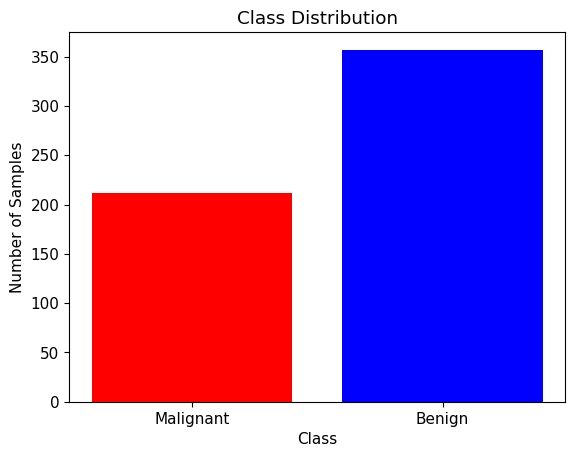


Minimum values per feature:
 [6.981e+00 9.710e+00 4.379e+01 1.435e+02 5.263e-02 1.938e-02 0.000e+00
 0.000e+00 1.060e-01 4.996e-02 1.115e-01 3.602e-01 7.570e-01 6.802e+00
 1.713e-03 2.252e-03 0.000e+00 0.000e+00 7.882e-03 8.948e-04 7.930e+00
 1.202e+01 5.041e+01 1.852e+02 7.117e-02 2.729e-02 0.000e+00 0.000e+00
 1.565e-01 5.504e-02]

Maximum values per feature:
 [2.811e+01 3.928e+01 1.885e+02 2.501e+03 1.634e-01 3.454e-01 4.268e-01
 2.012e-01 3.040e-01 9.744e-02 2.873e+00 4.885e+00 2.198e+01 5.422e+02
 3.113e-02 1.354e-01 3.960e-01 5.279e-02 7.895e-02 2.984e-02 3.604e+01
 4.954e+01 2.512e+02 4.254e+03 2.226e-01 1.058e+00 1.252e+00 2.910e-01
 6.638e-01 2.075e-01]

Observation:
Features are NOT on the same scale. Some have small values (0-1),
while others have very large values (hundreds or thousands).
Scaling is required before using distance-based models like SVM.


In [6]:
# ── Your code here ────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

# Load dataset
cancer = load_breast_cancer()

# =========================
# BASIC INFO
# =========================
print("Number of samples:", cancer.data.shape[0])
print("Number of features:", cancer.data.shape[1])
print("Class names:", cancer.target_names)

# =========================
# CLASS DISTRIBUTION
# =========================
benign_count = np.sum(cancer.target == 1)
malignant_count = np.sum(cancer.target == 0)

print("Benign samples:", benign_count)
print("Malignant samples:", malignant_count)

# =========================
# BAR CHART
# =========================
classes = ['Malignant', 'Benign']
counts = [malignant_count, benign_count]
colors = ['red', 'blue']

plt.bar(classes, counts, color=colors)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()

# =========================
# FEATURE RANGES
# =========================
feature_min = cancer.data.min(axis=0)
feature_max = cancer.data.max(axis=0)

print("\nMinimum values per feature:\n", feature_min)
print("\nMaximum values per feature:\n", feature_max)

# =========================
# OBSERVATION
# =========================
print("\nObservation:")
print("Features are NOT on the same scale. Some have small values (0-1),")
print("while others have very large values (hundreds or thousands).")
print("Scaling is required before using distance-based models like SVM.")



**💬 Think About It:**

*Are the two classes roughly balanced, or is one much larger?*  
*Are the feature value ranges similar or very different?*  
*What problem could very different feature ranges cause for SVM?*

<details><summary>💡 Reveal Solution</summary>

```python
# Basic info
print(f'Samples  : {cancer.data.shape[0]}')
print(f'Features : {cancer.data.shape[1]}')
print(f'Classes  : {list(cancer.target_names)}')
print()

# Counts per class
for i, name in enumerate(cancer.target_names):
    count = np.sum(cancer.target == i)
    print(f'  {name}: {count} samples ({count/len(cancer.target)*100:.1f}%)')

# Bar chart
counts = [np.sum(cancer.target == i) for i in range(2)]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(cancer.target_names, counts, color=['#E63946', '#457B9D'], edgecolor='k')
axes[0].set_title('Samples per Class', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[0].text(i, v+3, str(v), ha='center', fontweight='bold')

# Feature ranges
ranges = cancer.data.max(axis=0) - cancer.data.min(axis=0)
axes[1].bar(range(30), ranges, color='#2A9D8F', edgecolor='k')
axes[1].set_title('Feature Value Ranges\n(big differences → need scaling!)', fontweight='bold')
axes[1].set_xlabel('Feature index')
axes[1].set_ylabel('Max − Min')
plt.tight_layout(); plt.show()

print(f'Smallest range: {ranges.min():.4f}  |  Largest range: {ranges.max():.2f}')
print('Features are on very different scales → MUST scale before SVM!')
```
</details>

---
## ✏️ Task 2 — Train Your First SVM and Check if Scaling Matters

### Background
SVM finds the boundary by computing **distances** between data points.  
If one feature is 1000× larger than another, it will completely dominate those distance calculations — the model essentially ignores the small features.

`StandardScaler` fixes this by transforming every feature to have **mean = 0** and **standard deviation = 1**.  
After scaling, all features contribute equally.

⚠️ **The golden rule:** Always fit the scaler on training data only, then apply it to test data.  
If you fit it on the whole dataset, the model "peeks" at test data during training — this is called **data leakage**.

```
WRONG ❌:  scaler.fit(ALL data) → then split
RIGHT  ✅:  split first → scaler.fit(X_train) → scaler.transform(X_test)
```

### Steps
1. Split the cancer dataset: **80% train, 20% test**
2. Train `svm.SVC(kernel='linear', C=1)` on **raw (unscaled)** data → save test accuracy
3. Apply `StandardScaler` (fit on train only!), then train the same SVM on **scaled** data → save test accuracy
4. Print both accuracies side by side
5. How much did scaling help?

In [7]:
# ── Your code here ────────────────────────────────────────────────────────

# Load data
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# =========================
# 1. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 2. SVM WITHOUT SCALING
# =========================
model_raw = svm.SVC(kernel='linear', C=1)
model_raw.fit(X_train, y_train)

y_pred_raw = model_raw.predict(X_test)
acc_raw = accuracy_score(y_test, y_pred_raw)

# =========================
# 3. APPLY SCALING (CORRECT WAY)
# =========================
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

# =========================
# 4. SVM WITH SCALING
# =========================
model_scaled = svm.SVC(kernel='linear', C=1)
model_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = model_scaled.predict(X_test_scaled)
acc_scaled = accuracy_score(y_test, y_pred_scaled)

# =========================
# 5. RESULTS
# =========================
print("Accuracy WITHOUT scaling:", acc_raw)
print("Accuracy WITH scaling:   ", acc_scaled)

print("\nImprovement:", acc_scaled - acc_raw)

Accuracy WITHOUT scaling: 0.956140350877193
Accuracy WITH scaling:    0.9736842105263158

Improvement: 0.01754385964912286


**💬 Think About It:**

*How much did scaling improve accuracy?*  
*Why should we fit the scaler on training data only?*

<details><summary>💡 Reveal Solution</summary>

```python
X_tr, X_te, y_tr, y_te = train_test_split(
    cancer.data, cancer.target, test_size=0.2, random_state=42)

# Without scaling
clf_raw = svm.SVC(kernel='linear', C=1)
clf_raw.fit(X_tr, y_tr)
acc_raw = clf_raw.score(X_te, y_te)

# With scaling
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)   # fit on train, transform train
X_te_s = scaler.transform(X_te)       # transform test only — NO fitting!

clf_sc = svm.SVC(kernel='linear', C=1)
clf_sc.fit(X_tr_s, y_tr)
acc_sc = clf_sc.score(X_te_s, y_te)

print(f'WITHOUT scaling : {acc_raw*100:.1f}%')
print(f'WITH scaling    : {acc_sc*100:.1f}%')
print(f'Improvement     : +{(acc_sc - acc_raw)*100:.1f} percentage points')
print('\nAlways scale before SVM!')
```
</details>

---
## ✏️ Task 3 — What Are Support Vectors? Prove It.

### Background
The SVM boundary is decided by only a **tiny subset** of training points — the **support vectors**.  
These are the points sitting closest to the boundary, right on the edge of the margin.

The remarkable thing: if you **deleted every other training point**, the boundary would not change at all.  
Only deleting a support vector would move the boundary.

This task will let you **prove** this yourself.

### Steps
1. Using the scaled cancer data from Task 2, train `SVC(kernel='linear', C=1)`
2. Print: total training points vs number of support vectors — what % are SVs?
3. Find the **indices** of non-support-vector points using `clf.support_`
4. Remove **30 random non-SV points** from the training set and retrain
5. Compare test accuracy before and after — did it change?
6. Now try removing **just 1 support vector** and retrain — what happens?

> 💡 `clf.support_` → indices of support vectors in X_train  
> 💡 `np.setdiff1d(np.arange(len(X_tr_s)), clf.support_)` → non-SV indices

In [8]:
# ── Your code here ────────────────────────────────────────────────────────


# Load data
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# =========================
# 1. SPLIT + SCALE
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# =========================
# 2. TRAIN SVM
# =========================
clf = svm.SVC(kernel='linear', C=1)
clf.fit(X_train_s, y_train)

y_pred = clf.predict(X_test_s)
baseline_acc = accuracy_score(y_test, y_pred)

# =========================
# 3. SUPPORT VECTOR INFO
# =========================
n_total = len(X_train_s)
n_sv = len(clf.support_)

print("Total training points:", n_total)
print("Number of support vectors:", n_sv)
print("Percentage SVs:", (n_sv / n_total) * 100)

# =========================
# 4. REMOVE NON-SV POINTS
# =========================
non_sv_indices = np.setdiff1d(np.arange(n_total), clf.support_)

# Randomly remove 30 non-SV points
np.random.seed(42)
remove_non_sv = np.random.choice(non_sv_indices, size=30, replace=False)

mask = np.ones(n_total, dtype=bool)
mask[remove_non_sv] = False

X_train_reduced = X_train_s[mask]
y_train_reduced = y_train[mask]

# Retrain
clf_non_sv_removed = svm.SVC(kernel='linear', C=1)
clf_non_sv_removed.fit(X_train_reduced, y_train_reduced)

acc_non_sv_removed = accuracy_score(
    y_test, clf_non_sv_removed.predict(X_test_s)
)

# =========================
# 5. REMOVE ONE SUPPORT VECTOR
# =========================
remove_one_sv = clf.support_[0]  # remove first SV

mask_sv = np.ones(n_total, dtype=bool)
mask_sv[remove_one_sv] = False

X_train_sv_removed = X_train_s[mask_sv]
y_train_sv_removed = y_train[mask_sv]

clf_sv_removed = svm.SVC(kernel='linear', C=1)
clf_sv_removed.fit(X_train_sv_removed, y_train_sv_removed)

acc_sv_removed = accuracy_score(
    y_test, clf_sv_removed.predict(X_test_s)
)

# =========================
# 6. RESULTS
# =========================
print("\nBaseline accuracy:", baseline_acc)
print("After removing 30 NON-SV points:", acc_non_sv_removed)
print("After removing 1 SUPPORT VECTOR:", acc_sv_removed)


Total training points: 455
Number of support vectors: 32
Percentage SVs: 7.032967032967033

Baseline accuracy: 0.9736842105263158
After removing 30 NON-SV points: 0.9736842105263158
After removing 1 SUPPORT VECTOR: 0.9736842105263158


**💬 Think About It:**

*What percentage of training points are support vectors?*  
*Did removing 30 non-SVs change the accuracy?*  
*Did removing 1 support vector change the accuracy?*  
*What does this tell you about why they are called "support" vectors?*

<details><summary>💡 Reveal Solution</summary>

```python
clf = svm.SVC(kernel='linear', C=1)
clf.fit(X_tr_s, y_tr)
base_acc = clf.score(X_te_s, y_te)

n_sv   = len(clf.support_)
n_tot  = len(X_tr_s)
print(f'Training points : {n_tot}')
print(f'Support vectors : {n_sv}  ({n_sv/n_tot*100:.1f}% of training data)')
print(f'Non-SVs         : {n_tot - n_sv}')
print(f'Baseline accuracy: {base_acc:.4f}')

# Remove 30 random NON-support vectors
non_sv_idx = np.setdiff1d(np.arange(n_tot), clf.support_)
remove_30  = np.random.choice(non_sv_idx, size=30, replace=False)
keep_idx   = np.setdiff1d(np.arange(n_tot), remove_30)

clf_no30 = svm.SVC(kernel='linear', C=1)
clf_no30.fit(X_tr_s[keep_idx], y_tr[keep_idx])
acc_no30 = clf_no30.score(X_te_s, y_te)
print(f'\nAfter removing 30 non-SVs  : {acc_no30:.4f}  (change: {(acc_no30-base_acc)*100:+.2f}%)')

# Remove just 1 support vector
keep_no_sv1 = np.setdiff1d(np.arange(n_tot), [clf.support_[0]])
clf_nosv1 = svm.SVC(kernel='linear', C=1)
clf_nosv1.fit(X_tr_s[keep_no_sv1], y_tr[keep_no_sv1])
acc_nosv1 = clf_nosv1.score(X_te_s, y_te)
print(f'After removing 1 support vector: {acc_nosv1:.4f}  (change: {(acc_nosv1-base_acc)*100:+.2f}%)')
print('\nRemoving non-SVs = no effect. Removing a SV = boundary shifts!')
```
</details>

---
## ✏️ Task 4 — C in Action: Strict vs Forgiving

### Background
**C is the most important thing you control in SVM.**

Think of C as a dial between two extremes:

```
C very small               C very large
(Forgiving)                (Strict)
─────────────────────────────────────────────
"Mistakes are okay"        "No mistakes allowed"
Wide margin                Narrow margin
Simpler boundary           Complex boundary
May miss some patients     Memorises training data
UNDERFITTING               OVERFITTING
```

For cancer detection: a too-lenient model misses malignant cases. A too-strict one works on training data but fails on new patients.

### Steps
Using scaled cancer data from Task 2:
1. Test `C = [0.001, 0.01, 0.1, 1, 10, 100, 1000]` with `kernel='linear'`
2. For each C, record: training accuracy, test accuracy, number of support vectors
3. Print a clean table of results
4. Plot two lines: training acc (red) and test acc (blue) vs C on a log scale
5. Draw a vertical dashed green line at the best C (highest test accuracy)
6. What pattern do you see as C increases?

> 💡 When training accuracy goes to 100% but test accuracy drops → overfitting!  
> 💡 When both training and test accuracy are low → underfitting!

C        | Train Acc  | Test Acc   | Num SVs 
--------+-------------+-------------+----------
0.001    | 0.9407     | 0.9561     | 212     
0.01     | 0.9780     | 0.9649     | 99      
0.1      | 0.9846     | 0.9825     | 51      
1        | 0.9912     | 0.9737     | 32      
10       | 0.9912     | 0.9825     | 26      
100      | 0.9956     | 0.9737     | 26      
1000     | 1.0000     | 0.9298     | 24      


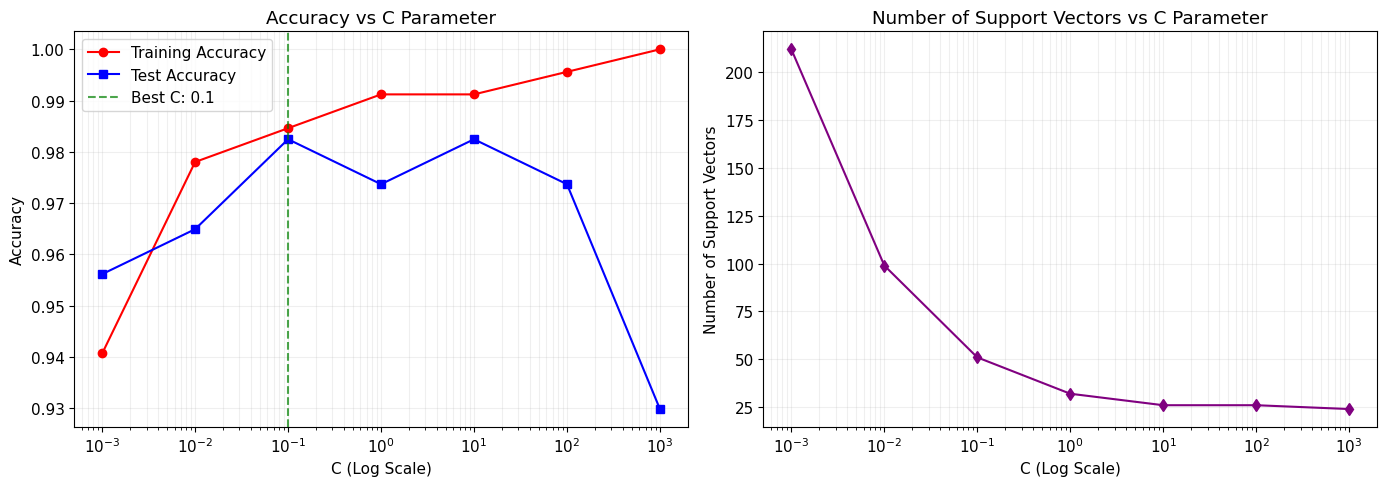


Best C for highest test accuracy: 0.1 with an accuracy of 0.9825


In [9]:
# ── Your code here ────────────────────────────────────────────────────────
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# =========================
# SPLIT + SCALE
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Using scaled cancer data from Task 2 (X_train_s, y_train, X_test_s, y_test)
# Ensure X_train_s, y_train, X_test_s, y_test are available from previous tasks or re-run setup cells

# Define C values to test
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

train_accuracies = []
test_accuracies = []
num_support_vectors = []

print(f'{"C":<8} | {"Train Acc":<10} | {"Test Acc":<10} | {"Num SVs":<8}')
print(f'{'-'*8}+-{'-'*12}+-{'-'*12}+-{'-'*9}')

for C_val in C_values:
    # Train SVM with current C value
    clf_c = svm.SVC(kernel='linear', C=C_val)
    clf_c.fit(X_train_s, y_train)

    # Record training and test accuracy
    train_acc = clf_c.score(X_train_s, y_train)
    test_acc = clf_c.score(X_test_s, y_test)

    # Record number of support vectors
    sv_count = len(clf_c.support_vectors_)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    num_support_vectors.append(sv_count)

    print(f'{C_val:<8} | {train_acc:<10.4f} | {test_acc:<10.4f} | {sv_count:<8}')

# Plotting results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot accuracy vs C
axes[0].semilogx(C_values, train_accuracies, 'o-', color='red', label='Training Accuracy')
axes[0].semilogx(C_values, test_accuracies, 's-', color='blue', label='Test Accuracy')
axes[0].set_xlabel('C (Log Scale)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs C Parameter')
axes[0].legend()
axes[0].grid(True, which="both", ls="-", alpha=0.2)

# Find the best C based on test accuracy
best_C_idx = np.argmax(test_accuracies)
best_C = C_values[best_C_idx]
axes[0].axvline(best_C, color='green', linestyle='--', label=f'Best C: {best_C}', alpha=0.7)
axes[0].legend()

# Plot number of support vectors vs C
axes[1].semilogx(C_values, num_support_vectors, 'd-', color='purple')
axes[1].set_xlabel('C (Log Scale)')
axes[1].set_ylabel('Number of Support Vectors')
axes[1].set_title('Number of Support Vectors vs C Parameter')
axes[1].grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()

print(f"\nBest C for highest test accuracy: {best_C} with an accuracy of {max(test_accuracies):.4f}")

**💬 Think About It:**

*At what C does training accuracy reach ~100%?*  
*At what C is the test accuracy highest?*  
*What happens to the number of support vectors as C increases?*  
*Is the best C for training accuracy the same as the best C for test accuracy?*

<details><summary>💡 Reveal Solution</summary>

```python
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
tr_accs, te_accs, n_svs = [], [], []

print(f'{"C":>8}  {"Train Acc":>10}  {"Test Acc":>10}  {"Num SVs":>8}')
print('-' * 45)
for C in C_values:
    clf_c = svm.SVC(kernel='linear', C=C)
    clf_c.fit(X_tr_s, y_tr)
    tr = clf_c.score(X_tr_s, y_tr)
    te = clf_c.score(X_te_s, y_te)
    sv = len(clf_c.support_vectors_)
    tr_accs.append(tr); te_accs.append(te); n_svs.append(sv)
    note = ' ← overfit?' if tr - te > 0.03 else ('  ← underfit?' if tr < 0.93 else '')
    print(f'{C:>8}  {tr:>10.4f}  {te:>10.4f}  {sv:>8}{note}')

best_C = C_values[np.argmax(te_accs)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].semilogx(C_values, tr_accs, 'o-', color='#E63946', label='Training accuracy')
axes[0].semilogx(C_values, te_accs, 's-', color='#457B9D', label='Test accuracy')
axes[0].axvline(best_C, color='green', lw=2, linestyle='--', label=f'Best C = {best_C}')
axes[0].set_xlabel('C  (log scale)'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('C vs Accuracy\n(gap = overfitting!)', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].semilogx(C_values, n_svs, 'D-', color='#F4A261')
axes[1].set_xlabel('C  (log scale)'); axes[1].set_ylabel('Number of Support Vectors')
axes[1].set_title('C vs Number of Support Vectors\n(strict C → fewer SVs)', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f'\nBest C = {best_C}  →  Test accuracy = {max(te_accs):.4f}')
```
</details>

---
## ✏️ Task 5 — The Confusion Matrix: Not All Mistakes Are Equal

### Background
Accuracy tells you how many predictions were right overall — but it hides the **type** of mistake.

In cancer diagnosis:

| The model said... | Reality | Type | Consequence |
|---|---|---|---|
| Benign | Actually Malignant | **False Negative** | 🚨 Patient goes home — cancer untreated! |
| Malignant | Actually Benign | **False Positive** | 😟 Extra tests — stressful but safe |

A **False Negative** is far more dangerous here.  
So the question is: **does choosing a different C reduce dangerous mistakes?**

### Steps
1. Train SVMs with `C = 0.01, 1, 100` (kernel='linear', scaled data)
2. For each, plot a confusion matrix (3 subplots side by side)
3. Print the number of False Negatives for each C
4. Does higher C always mean fewer dangerous mistakes?

> 💡 False Negatives = `confusion_matrix(y_te, y_pred)[0, 1]`  
> (Row 0 = actual malignant, Column 1 = predicted benign)

C = 0.01 → False Negatives: 3
C = 1 → False Negatives: 1
C = 100 → False Negatives: 2


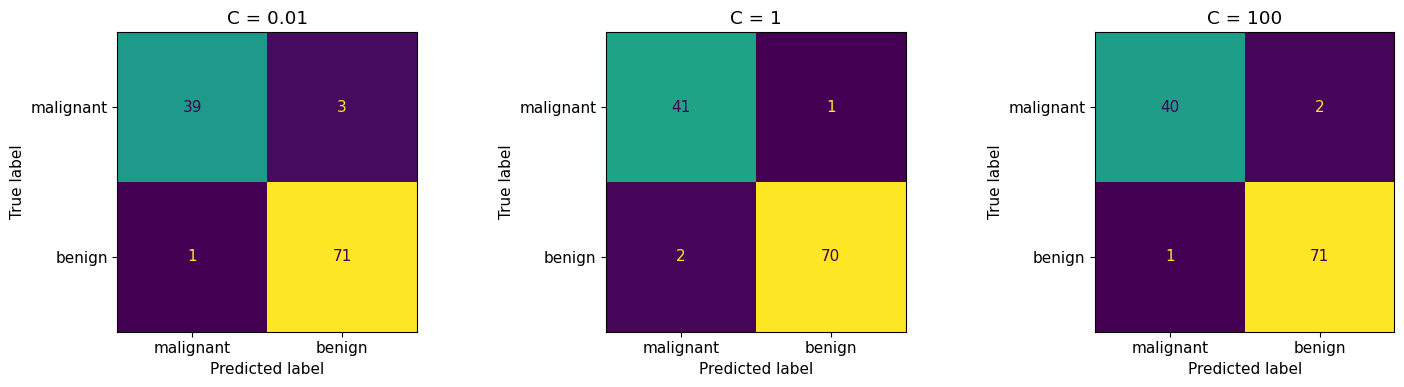

In [10]:
# ── Your code here ────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load data
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# =========================
# SPLIT + SCALE
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# =========================
# TEST C VALUES
# =========================
C_values = [0.01, 1, 100]

plt.figure(figsize=(15, 4))

false_negatives = []

for i, C in enumerate(C_values):
    clf = SVC(kernel='linear', C=C)
    clf.fit(X_train_s, y_train)

    y_pred = clf.predict(X_test_s)

    cm = confusion_matrix(y_test, y_pred)

    # Extract False Negatives
    fn = cm[0, 1]
    false_negatives.append(fn)

    print(f"C = {C} → False Negatives: {fn}")

    # Plot
    plt.subplot(1, 3, i + 1)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=cancer.target_names)
    disp.plot(ax=plt.gca(), colorbar=False)
    plt.title(f"C = {C}")

plt.tight_layout()
plt.show()




**💬 Think About It:**

*Which C gives the fewest false negatives (missed cancers)?*  
*Is the C with best overall accuracy also safest for the patient?*  
*What does this tell you about choosing metrics in real-world problems?*

<details><summary>💡 Reveal Solution</summary>

```python
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
print(f'{"C":>6}  {"Accuracy":>10}  {"False Negatives (missed cancer!)":>32}')
print('-' * 55)

for ax, C in zip(axes, [0.01, 1, 100]):
    clf_c = svm.SVC(kernel='linear', C=C)
    clf_c.fit(X_tr_s, y_tr)
    y_pred = clf_c.predict(X_te_s)
    acc = clf_c.score(X_te_s, y_te)
    fn  = confusion_matrix(y_te, y_pred)[0, 1]
    print(f'{C:>6}  {acc:>10.4f}  {fn:>32}')
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred, display_labels=cancer.target_names,
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'C = {C}\nAcc={acc:.2f}  False Neg={fn}', fontweight='bold')

plt.suptitle('Breast Cancer: How C Affects Mistake Types', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
```
</details>

---
---
# 🌸 PART 2 — Iris Flowers
## "Can a machine tell flower species apart from petal measurements?"

The Iris dataset has 3 species — **Setosa**, **Versicolor**, **Virginica**.  
Only 4 measurements: sepal length, sepal width, petal length, petal width.

This part is perfect for **visualising** what SVM is doing — we can draw the decision boundary in 2D.  
You will see the margin, the support vectors, and the effect of different kernels with your own eyes.

---

## ✏️ Task 6 — See the Boundary: What SVM Actually Learns

### Background
When we have more than 2 features, we cannot draw the decision boundary directly.  
But if we **pick just 2 features**, we can make a 2D plot that shows:
- The **coloured regions**: what the model would predict for any new flower landing there
- The **boundary**: the line separating the regions
- The **gold circles**: the support vectors — the flowers closest to the boundary

### Steps
1. Use **only petal length and petal width** (columns 2 and 3) from Iris
2. Scale with `StandardScaler`
3. Train `SVC(kernel='linear', C=1)` on the full dataset (no split needed — just for visualisation)
4. Plot the decision boundary:
   - Shade each region in the class colour
   - Scatter the actual training points (different colour per species)
   - Highlight support vectors with gold circles
5. Label the axes: "Petal Length" and "Petal Width"
6. Print: how many support vectors are there for a 3-class problem?

> 💡 For a 3-class problem, `clf.support_vectors_` contains SVs from all class boundaries

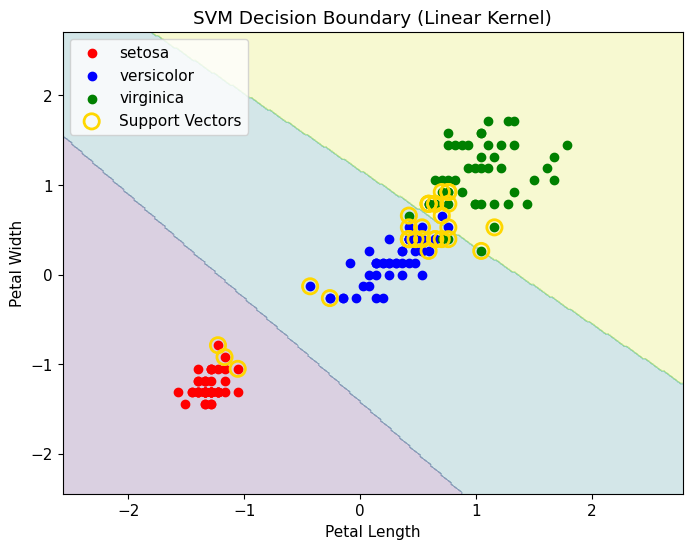

Support vectors per class: [ 3 15 13]
Total support vectors: 31


In [11]:
# ── Your code here ────────────────────────────────────────────────────────

# Load data
iris = datasets.load_iris()

# Use only petal length & petal width
X = iris.data[:, 2:4]
y = iris.target

# =========================
# SCALE FEATURES
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# TRAIN SVM
# =========================
clf = svm.SVC(kernel='linear', C=1)
clf.fit(X_scaled, y)

# =========================
# CREATE GRID (for regions)
# =========================
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Predict on grid
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# =========================
# PLOT
# =========================
plt.figure(figsize=(8,6))

# Background regions
plt.contourf(xx, yy, Z, alpha=0.2)

# Scatter original points
colors = ['red', 'blue', 'green']
labels = iris.target_names

for i, color in enumerate(colors):
    plt.scatter(
        X_scaled[y == i, 0],
        X_scaled[y == i, 1],
        color=color,
        label=labels[i]
    )

# =========================
# SUPPORT VECTORS (gold circles)
# =========================
plt.scatter(
    clf.support_vectors_[:, 0],
    clf.support_vectors_[:, 1],
    s=120,
    facecolors='none',
    edgecolors='gold',
    linewidth=2,
    label='Support Vectors'
)

# Labels
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("SVM Decision Boundary (Linear Kernel)")
plt.legend()

plt.show()

# =========================
# SUPPORT VECTOR COUNT
# =========================
print("Support vectors per class:", clf.n_support_)
print("Total support vectors:", len(clf.support_vectors_))


**💬 Think About It:**

*Can you see the margin (the gap between the classes and the boundary)?*  
*Which species is easiest to separate? Which is hardest?*  
*Where are most of the support vectors located?*

<details><summary>💡 Reveal Solution</summary>

```python
X_petal = iris.data[:, 2:4]   # petal length, petal width
X_petal_s = StandardScaler().fit_transform(X_petal)

clf_iris = svm.SVC(kernel='linear', C=1)
clf_iris.fit(X_petal_s, iris.target)

# Build grid for background colours
x_min, x_max = X_petal_s[:,0].min()-0.5, X_petal_s[:,0].max()+0.5
y_min, y_max = X_petal_s[:,1].min()-0.5, X_petal_s[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min,x_max,300), np.linspace(y_min,y_max,300))
Z = clf_iris.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)

COLORS3 = ['#E63946', '#2A9D8F', '#457B9D']
fig, ax = plt.subplots(figsize=(7, 6))
ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.RdYlBu)

for cls, color, name in zip([0,1,2], COLORS3, iris.target_names):
    mask = iris.target == cls
    ax.scatter(X_petal_s[mask,0], X_petal_s[mask,1],
               c=color, edgecolors='k', s=60, label=name, zorder=3)

sv = clf_iris.support_vectors_
ax.scatter(sv[:,0], sv[:,1], s=220, facecolors='none',
           edgecolors='gold', lw=2.5, zorder=4, label=f'Support Vectors ({len(sv)})')

ax.set_xlabel('Petal Length (scaled)', fontsize=12)
ax.set_ylabel('Petal Width (scaled)',  fontsize=12)
ax.set_title('Iris — Linear SVM Decision Boundary\nColoured regions = what the model predicts', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()
print(f'Number of support vectors: {len(sv)}')
```
</details>

---
## ✏️ Task 7 — C Changes the Boundary Shape: See It!

### Background
When C is **small**, the SVM prioritises a wide margin — even if a few points end up on the wrong side.  
When C is **large**, the SVM tries hard to classify every point correctly — the margin gets tighter.

The visual difference is very clear on this dataset. Let us look at it directly.

### Steps
Using petal features (scaled) from Task 6:
1. Train **4 linear SVMs** with `C = [0.01, 0.1, 1, 100]`
2. Plot all 4 decision boundaries in a row
3. In each title, show: C value, training accuracy, number of support vectors
4. Highlight support vectors in gold on each plot
5. As C increases, what happens to: the boundary, the support vectors, the accuracy?

> 💡 You are looking for: margin width, how many points the boundary tries to separate, and how complex the regions look

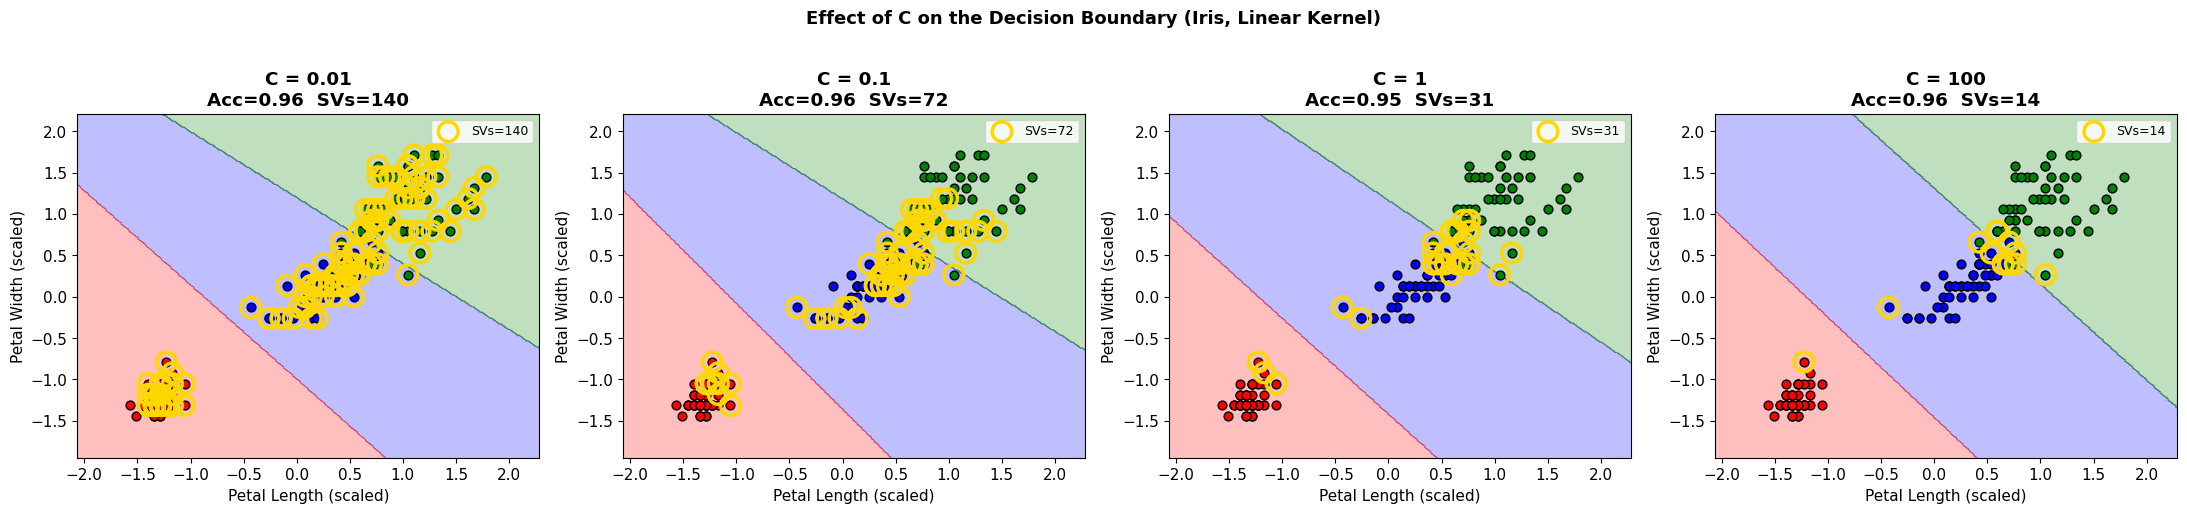

In [12]:
# ── Your code here ────────────────────────────────────────────────────────
# Using petal features (scaled) from Task 6
X_petal = iris.data[:, 2:4]   # petal length, petal width
scaler = StandardScaler()
X_petal_s = scaler.fit_transform(X_petal)
y = iris.target

C_vals = [0.01, 0.1, 1, 100]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, C in zip(axes, C_vals):
    clf_c = svm.SVC(kernel='linear', C=C)
    clf_c.fit(X_petal_s, y)

    # Build grid for background colours
    x_min, x_max = X_petal_s[:,0].min()-0.5, X_petal_s[:,0].max()+0.5
    y_min, y_max = X_petal_s[:,1].min()-0.5, X_petal_s[:,1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min,x_max,300), np.linspace(y_min,y_max,300))
    Z = clf_c.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)

    # Define colors for the classes
    COLORS3 = ['red', 'blue', 'green'] # Consistent with previous tasks for Iris

    ax.contourf(xx, yy, Z, alpha=0.25, cmap=ListedColormap(COLORS3[:len(np.unique(y))]))

    for cls, color in zip(np.unique(y), COLORS3):
        mask = y == cls
        ax.scatter(X_petal_s[mask,0], X_petal_s[mask,1],
                   c=color, edgecolors='k', s=40, zorder=3)

    sv = clf_c.support_vectors_
    ax.scatter(sv[:,0], sv[:,1], s=200, facecolors='none',
               edgecolors='gold', lw=2.5, zorder=4, label=f'SVs={len(sv)}')

    acc = clf_c.score(X_petal_s, y)
    ax.set_title(f'C = {C}\nAcc={acc:.2f}  SVs={len(sv)}', fontweight='bold')
    ax.set_xlabel('Petal Length (scaled)')
    ax.set_ylabel('Petal Width (scaled)')
    ax.legend(fontsize=9)

plt.suptitle('Effect of C on the Decision Boundary (Iris, Linear Kernel)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**💬 Think About It:**

*Does the number of support vectors go up or down as C increases?*  
*Does the boundary look more complex or simpler with large C?*  
*If you had to pick one C for new, unseen flowers, which would you pick and why?*

<details><summary>💡 Reveal Solution</summary>

```python
C_vals = [0.01, 0.1, 1, 100]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, C in zip(axes, C_vals):
    clf_c = svm.SVC(kernel='linear', C=C)
    clf_c.fit(X_petal_s, iris.target)

    x_min,x_max = X_petal_s[:,0].min()-0.5, X_petal_s[:,0].max()+0.5
    y_min,y_max = X_petal_s[:,1].min()-0.5, X_petal_s[:,1].max()+0.5
    xx,yy = np.meshgrid(np.linspace(x_min,x_max,300), np.linspace(y_min,y_max,300))
    Z = clf_c.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.RdYlBu)
    for cls, color in zip([0,1,2], ['#E63946','#2A9D8F','#457B9D']):
        mask = iris.target == cls
        ax.scatter(X_petal_s[mask,0], X_petal_s[mask,1],
                   c=color, edgecolors='k', s=40, zorder=3)

    sv = clf_c.support_vectors_
    ax.scatter(sv[:,0], sv[:,1], s=200, facecolors='none',
               edgecolors='gold', lw=2.5, zorder=4, label=f'SVs={len(sv)}')

    acc = clf_c.score(X_petal_s, iris.target)
    ax.set_title(f'C = {C}\nAcc={acc:.2f}  SVs={len(sv)}', fontweight='bold')
    ax.set_xlabel('Petal Length (scaled)')
    ax.set_ylabel('Petal Width (scaled)')
    ax.legend(fontsize=9)

plt.suptitle('Effect of C on the Decision Boundary (Iris, Linear Kernel)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
```
</details>

---
## ✏️ Task 8 — Linear vs RBF vs Polynomial: Which Boundary Fits Best?

### Background
Different kernels draw different types of boundaries:

| Kernel | Type of boundary it can draw |
|---|---|
| **Linear** | Straight lines only |
| **RBF** | Smooth curves in any direction |
| **Polynomial** | Curved boundaries based on feature combinations |

For the Iris dataset, some classes might need curved boundaries to be properly separated.  
The question is: does the extra complexity of RBF or Polynomial actually help?

### Steps
1. Split petal data 70/30 train/test, scale
2. Train 3 models: `kernel='linear'`, `kernel='rbf'`, `kernel='poly'` — all with `C=1`
3. For each: plot decision boundary, show train AND test accuracy in the title
4. Print a comparison table
5. Which kernel generalises best? Is the most complex boundary always the best?

> 💡 Use `kernel='poly'` with default settings — no need to tune degree  
> 💡 A model with high train accuracy but lower test accuracy is overfitting

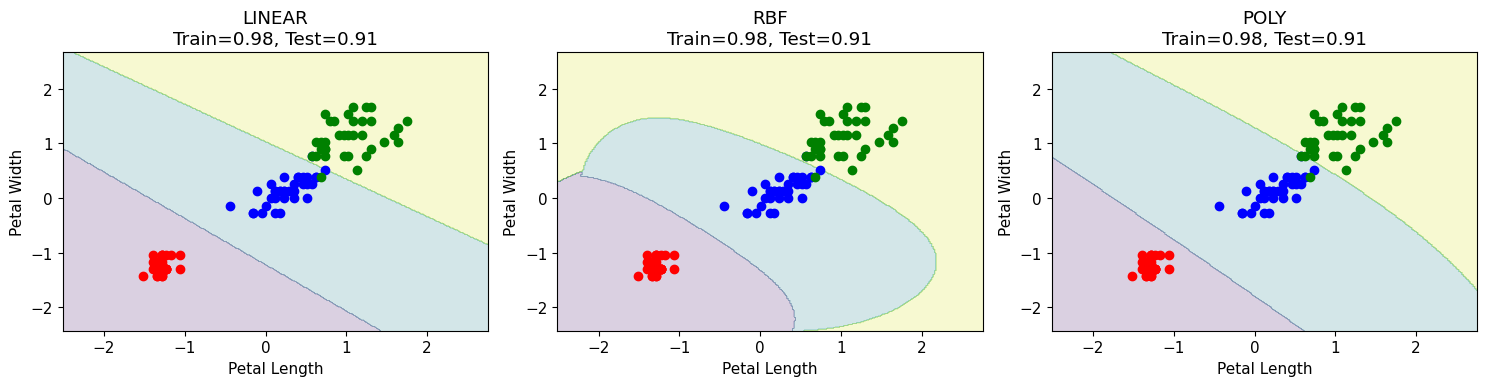


Kernel Comparison
Kernel    Train Acc      Test Acc
-----------------------------------
linear    0.9810         0.9111
rbf       0.9810         0.9111
poly      0.9810         0.9111


In [13]:
# ── Your code here ────────────────────────────────────────────────────────

# Load data (petal features only)
iris = datasets.load_iris()
X = iris.data[:, 2:4]
y = iris.target

# =========================
# SPLIT + SCALE
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# =========================
# MODELS
# =========================
kernels = ['linear', 'rbf', 'poly']

results = []

plt.figure(figsize=(15, 4))

for i, kernel in enumerate(kernels):

    clf = svm.SVC(kernel=kernel, C=1)
    clf.fit(X_train_s, y_train)

    # Accuracy
    train_acc = accuracy_score(y_train, clf.predict(X_train_s))
    test_acc = accuracy_score(y_test, clf.predict(X_test_s))

    results.append((kernel, train_acc, test_acc))

    # =========================
    # DECISION BOUNDARY
    # =========================
    plt.subplot(1, 3, i+1)

    x_min, x_max = X_train_s[:, 0].min() - 1, X_train_s[:, 0].max() + 1
    y_min, y_max = X_train_s[:, 1].min() - 1, X_train_s[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.2)

    # Plot training points
    colors = ['red', 'blue', 'green']
    for j in range(3):
        plt.scatter(
            X_train_s[y_train == j, 0],
            X_train_s[y_train == j, 1],
            color=colors[j]
        )

    plt.title(f"{kernel.upper()}\nTrain={train_acc:.2f}, Test={test_acc:.2f}")
    plt.xlabel("Petal Length")
    plt.ylabel("Petal Width")

plt.tight_layout()
plt.show()

# =========================
# PRINT TABLE
# =========================
print("\nKernel Comparison")
print(f"{'Kernel':<10}{'Train Acc':<15}{'Test Acc'}")
print("-" * 35)

for k, tr, te in results:
    print(f"{k:<10}{tr:<15.4f}{te:.4f}")


**💬 Think About It:**

*Which kernel gives the highest test accuracy?*  
*Does linear kernel underperform because the classes need curved boundaries?*  
*Is a more complex kernel always better?*

<details><summary>💡 Reveal Solution</summary>

```python
X_pet = iris.data[:, 2:4]
X_ptr, X_pte, y_ptr, y_pte = train_test_split(X_pet, iris.target, test_size=0.3, random_state=0)
sc = StandardScaler()
X_ptr_s = sc.fit_transform(X_ptr)
X_pte_s = sc.transform(X_pte)

kernels = [('linear', {}), ('rbf', {}), ('poly', {})]
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

print(f'{"Kernel":>10}  {"Train Acc":>10}  {"Test Acc":>10}')
print('-' * 35)
for ax, (k, params) in zip(axes, kernels):
    clf_k = svm.SVC(kernel=k, C=1, **params)
    clf_k.fit(X_ptr_s, y_ptr)
    tr = clf_k.score(X_ptr_s, y_ptr)
    te = clf_k.score(X_pte_s, y_pte)
    print(f'{k:>10}  {tr:>10.4f}  {te:>10.4f}')

    x_min,x_max = X_ptr_s[:,0].min()-0.5, X_ptr_s[:,0].max()+0.5
    y_min,y_max = X_ptr_s[:,1].min()-0.5, X_ptr_s[:,1].max()+0.5
    xx,yy = np.meshgrid(np.linspace(x_min,x_max,300), np.linspace(y_min,y_max,300))
    Z = clf_k.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.RdYlBu)
    for cls, color, name in zip([0,1,2],['#E63946','#2A9D8F','#457B9D'],iris.target_names):
        m = y_ptr == cls
        ax.scatter(X_ptr_s[m,0],X_ptr_s[m,1],c=color,edgecolors='k',s=40,label=name,zorder=3)
    sv = clf_k.support_vectors_
    ax.scatter(sv[:,0],sv[:,1],s=180,facecolors='none',edgecolors='gold',lw=2,zorder=4)
    ax.set_title(f'{k.capitalize()} Kernel\nTrain={tr:.2f}  Test={te:.2f}', fontweight='bold')
    ax.set_xlabel('Petal Length'); ax.set_ylabel('Petal Width')
    ax.legend(fontsize=8)

plt.suptitle('Iris: Comparing Kernels', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
```
</details>

---
---
# ✍️ PART 3 — Handwritten Digits
## "Can SVM read handwriting?"

The Digits dataset has 1797 images, each an 8×8 pixel photo of a handwritten digit 0–9.  
Every pixel is a feature → **64 features** per image.

This is a **10-class** problem — much harder than yes/no.  
It shows how SVM scales to real perception tasks, and gives you a chance to inspect what mistakes look like.

---

## ✏️ Task 9 — See the Data: Display the Images

### Background
For image data, **always look at what you are training on**.  
It helps you understand why certain digits might be confused.  
A badly-written 4 can look like a 9. A 1 can look like a 7.

### Steps
1. Display a 5×10 grid: 5 rows = 5 random examples, 10 columns = one per digit (0–9)
2. Each image should be shown in grayscale
3. Add a column header for each digit (0, 1, 2 … 9)
4. Print: total number of images and pixels per image
5. Look carefully — which digits look most similar to each other?

> 💡 `digits.images[i]` is the 8×8 pixel array for sample i  
> 💡 `np.where(digits.target == d)[0]` gives all indices for digit d

Total images : 1797
Image size   : 8x8 = 64 pixels (features) per image


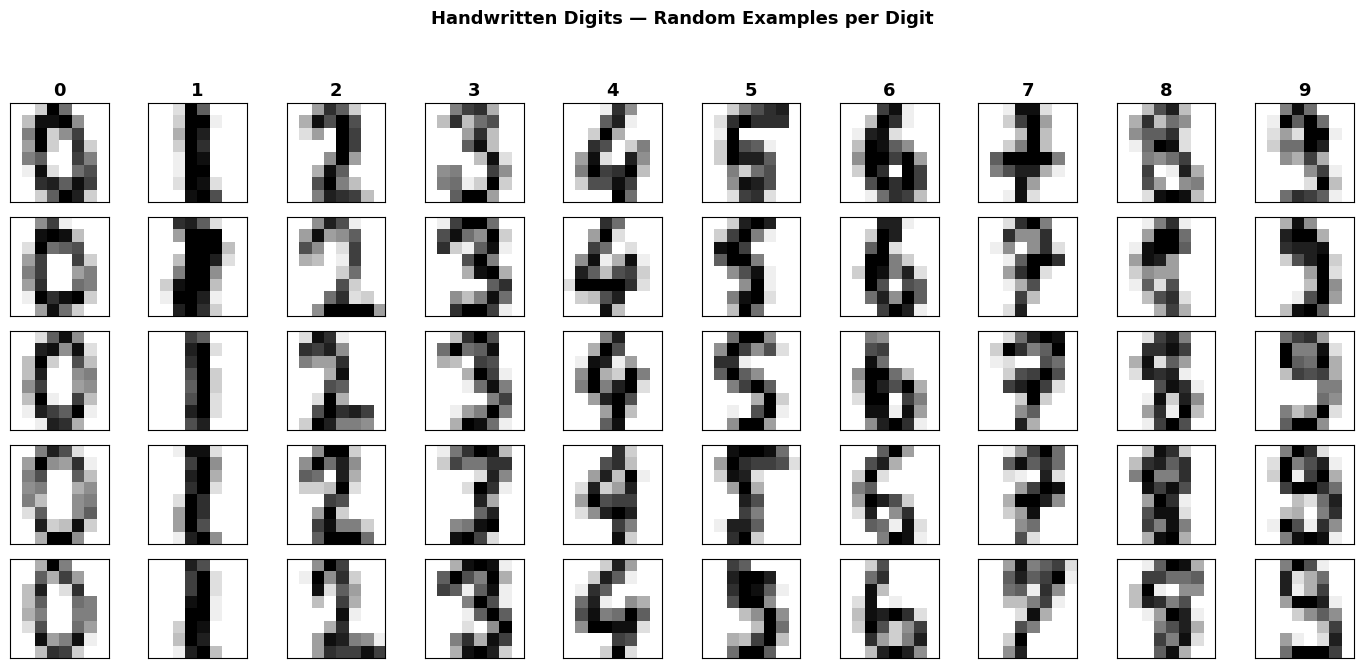

In [14]:
# ── Your code here ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits

digits = load_digits()

print(f'Total images : {digits.data.shape[0]}')
print(f'Image size   : 8x8 = {digits.data.shape[1]} pixels (features) per image')

fig, axes = plt.subplots(5, 10, figsize=(14, 7))
for col in range(10):
    # Get indices for the current digit
    digit_indices = np.where(digits.target == col)[0]
    # Randomly select 5 examples, or fewer if not enough exist
    selected_indices = np.random.choice(digit_indices, size=min(5, len(digit_indices)), replace=False)

    for row, idx in enumerate(selected_indices):
        ax = axes[row, col]
        ax.imshow(digits.images[idx], cmap='gray_r')
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title(str(col), fontsize=13, fontweight='bold')

# Hide unused subplots if fewer than 5 examples were available for a digit
for col in range(10):
    digit_indices = np.where(digits.target == col)[0]
    if len(digit_indices) < 5:
        for row in range(len(digit_indices), 5):
            fig.delaxes(axes[row, col])

plt.suptitle('Handwritten Digits — Random Examples per Digit', fontweight='bold', fontsize=13)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()


**💬 Think About It:**

*Just by looking — which digit pairs do you think an SVM might confuse?*  
*Does the handwriting vary a lot within the same digit?*

<details><summary>💡 Reveal Solution</summary>

```python
print(f'Total images : {digits.data.shape[0]}')
print(f'Image size   : 8×8 = {digits.data.shape[1]} pixels (features) per image')

fig, axes = plt.subplots(5, 10, figsize=(14, 7))
for col in range(10):
    idxs = np.where(digits.target == col)[0][:5]
    for row, idx in enumerate(idxs):
        ax = axes[row, col]
        ax.imshow(digits.images[idx], cmap='gray_r')
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(str(col), fontsize=13, fontweight='bold')

plt.suptitle('Handwritten Digits — 5 Examples per Digit', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()
```
</details>

---
## ✏️ Task 10 — Which Kernel Works Best on Images?

### Background
With 64 pixel features, the data lives in a **very high-dimensional space**.  
In high dimensions, linear boundaries can actually work surprisingly well — many complex patterns become linearly separable when you have enough features.

But non-linear kernels can also capture pixel relationships that linear cannot.  
Let us compare them head to head.

### Steps
1. Split Digits: 80% train, 20% test
2. Scale with `StandardScaler`
3. Train one model each: `kernel='linear'`, `kernel='rbf'`, `kernel='poly'` — all `C=1`
4. For each: print training accuracy and test accuracy
5. Make a grouped bar chart: 3 kernels on x-axis, two bars each (train acc, test acc)
6. Which kernel surprises you most?

> 💡 Tip: with 64 features, even a linear SVM can do very well!

Kernel    Train Acc      Test Acc
-----------------------------------
linear    1.0000         0.9750
rbf       0.9972         0.9750
poly      0.9826         0.9722


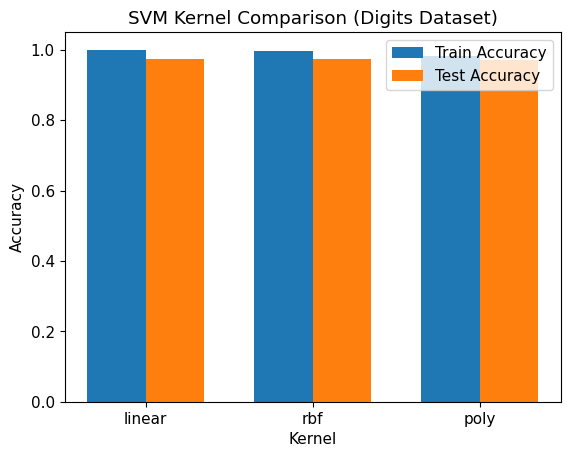

In [15]:
# ── Your code here ────────────────────────────────────────────────────────


import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load data
digits = load_digits()
X = digits.data   # 64 features (8x8 pixels flattened)
y = digits.target

# =========================
# SPLIT + SCALE
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# =========================
# MODELS
# =========================
kernels = ['linear', 'rbf', 'poly']

train_acc = []
test_acc = []

for kernel in kernels:
    clf = SVC(kernel=kernel, C=1)
    clf.fit(X_train_s, y_train)

    train_acc.append(accuracy_score(y_train, clf.predict(X_train_s)))
    test_acc.append(accuracy_score(y_test, clf.predict(X_test_s)))

# =========================
# PRINT RESULTS
# =========================
print(f"{'Kernel':<10}{'Train Acc':<15}{'Test Acc'}")
print("-" * 35)

for i, k in enumerate(kernels):
    print(f"{k:<10}{train_acc[i]:<15.4f}{test_acc[i]:.4f}")

# =========================
# BAR CHART
# =========================
x = np.arange(len(kernels))
width = 0.35

plt.figure()

plt.bar(x - width/2, train_acc, width, label='Train Accuracy')
plt.bar(x + width/2, test_acc, width, label='Test Accuracy')

plt.xticks(x, kernels)
plt.xlabel("Kernel")
plt.ylabel("Accuracy")
plt.title("SVM Kernel Comparison (Digits Dataset)")
plt.legend()

plt.show()


**💬 Think About It:**

*Did the linear kernel do better or worse than you expected on 64 features?*  
*Which kernel generalises best (smallest gap between train and test)?*  
*Why might the polynomial kernel struggle on image data?*

<details><summary>💡 Reveal Solution</summary>

```python
X_d_tr, X_d_te, y_d_tr, y_d_te = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42)
sc_d = StandardScaler()
X_d_tr_s = sc_d.fit_transform(X_d_tr)
X_d_te_s  = sc_d.transform(X_d_te)

kernels  = ['linear', 'rbf', 'poly']
tr_accs2 = []; te_accs2 = []

print(f'{"Kernel":>10}  {"Train Acc":>10}  {"Test Acc":>10}')
print('-' * 35)
for k in kernels:
    clf_k = svm.SVC(kernel=k, C=1)
    clf_k.fit(X_d_tr_s, y_d_tr)
    tr = clf_k.score(X_d_tr_s, y_d_tr)
    te = clf_k.score(X_d_te_s,  y_d_te)
    tr_accs2.append(tr); te_accs2.append(te)
    print(f'{k:>10}  {tr:>10.4f}  {te:>10.4f}')

x = np.arange(len(kernels))
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x-0.2, tr_accs2, 0.4, label='Train', color='#E63946', edgecolor='k')
ax.bar(x+0.2, te_accs2, 0.4, label='Test',  color='#457B9D', edgecolor='k')
ax.set_xticks(x); ax.set_xticklabels(kernels)
ax.set_ylim(0.8, 1.02); ax.set_ylabel('Accuracy')
ax.set_title('Digits: Kernel Comparison  (C=1)', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
```
</details>

---
## ✏️ Task 11 — C Matters Here Too: Tune It on the Best Kernel

### Background
You found the best kernel in Task 10. Now let us tune C for that kernel.

Remember the C rule:
- Too small → model is too lenient → underfits → low accuracy on both train and test
- Too large → model is too strict → overfits → high train accuracy, lower test accuracy
- Just right → the gap between train and test is small, and test accuracy is high

### Steps
1. Use the best kernel from Task 10 (probably `rbf`)
2. Test `C = [0.01, 0.1, 1, 10, 100]`
3. For each C, record train accuracy and **5-fold cross-validation accuracy** (better than test for tuning!)
4. Plot both vs C on a log-scale x-axis
5. Mark the best C with a vertical dashed line
6. Print the best C and what accuracy it achieves

> 💡 Use CV accuracy (not test accuracy) to choose C — the test set should only be used once at the very end!  
> 💡 `cross_val_score(clf, X_train, y_train, cv=5).mean()` gives 5-fold CV score

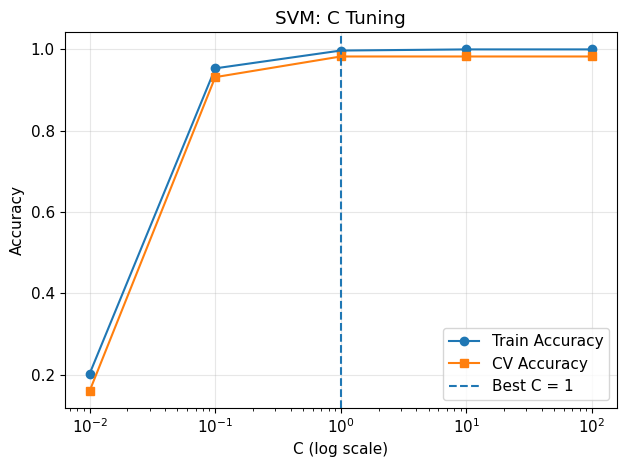

Best C: 1
Best CV Accuracy: 0.9826


In [16]:
# ── Your code here ────────────────────────────────────────────────────────


from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# Use your best kernel (assume 'rbf')
kernel = 'rbf'

C_values = [0.01, 0.1, 1, 10, 100]

train_acc = []
cv_acc = []

for c in C_values:
    clf = SVC(kernel=kernel, C=c, random_state=42)

    # Train accuracy
    clf.fit(X_train_s, y_train)
    train_acc.append(accuracy_score(y_train, clf.predict(X_train_s)))

    # 5-fold Cross Validation accuracy
    scores = cross_val_score(clf, X_train_s, y_train, cv=5)
    cv_acc.append(scores.mean())

# Find best C (based on CV accuracy)
best_index = np.argmax(cv_acc)
best_C = C_values[best_index]
best_score = cv_acc[best_index]

# Plot
plt.plot(C_values, train_acc, 'o-', label='Train Accuracy')
plt.plot(C_values, cv_acc, 's-', label='CV Accuracy')

plt.xscale('log')  # IMPORTANT (log scale)
plt.axvline(best_C, linestyle='--', label=f'Best C = {best_C}')

plt.xlabel('C (log scale)')
plt.ylabel('Accuracy')
plt.title('SVM: C Tuning')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print result
print(f'Best C: {best_C}')
print(f'Best CV Accuracy: {best_score:.4f}')

**💬 Think About It:**

*What is the best C according to CV accuracy?*  
*Is there a region where training accuracy is perfect (1.00) but CV drops?*  
*Why do we use cross-validation to pick C, not just look at test accuracy?*

<details><summary>💡 Reveal Solution</summary>

```python
C_vals = [0.01, 0.1, 1, 10, 100]
tr_list, cv_list = [], []

print(f'{"C":>6}  {"Train Acc":>10}  {"CV Acc":>8}  Status')
print('-' * 45)
for C in C_vals:
    clf_c = svm.SVC(kernel='rbf', C=C)
    clf_c.fit(X_d_tr_s, y_d_tr)
    tr = clf_c.score(X_d_tr_s, y_d_tr)
    cv = cross_val_score(clf_c, X_d_tr_s, y_d_tr, cv=5).mean()
    tr_list.append(tr); cv_list.append(cv)
    status = '⚠️  Overfit' if tr - cv > 0.05 else ('⚠️  Underfit' if cv < 0.9 else '✅  Good')
    print(f'{C:>6}  {tr:>10.4f}  {cv:>8.4f}  {status}')

best_C = C_vals[np.argmax(cv_list)]
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(C_vals, tr_list, 'o-', color='#E63946', label='Train accuracy')
ax.semilogx(C_vals, cv_list, 's-', color='#457B9D', label='CV accuracy')
ax.axvline(best_C, color='green', lw=2.5, linestyle='--', label=f'Best C = {best_C}')
ax.fill_between(C_vals, tr_list, cv_list, alpha=0.1, color='red', label='Overfit gap')
ax.set_xlabel('C  (log scale)'); ax.set_ylabel('Accuracy')
ax.set_title('Digits RBF: Choosing the Best C', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Best C = {best_C}  |  CV accuracy = {max(cv_list):.4f}')
```
</details>

---
## ✏️ Task 12 — Look at the Mistakes

### Background
One of the best ways to build intuition for your model is to look at **what it got wrong**.  
Bad predictions are not random — they usually happen for a reason, and inspecting them helps you understand the model's limitations.

For handwritten digits, mistakes often involve digits that genuinely look similar — like 4 and 9, or 3 and 8.

### Steps
1. Train the best model from Task 11 (best kernel + best C) on the full training set
2. Predict on the test set
3. Find all the **wrong predictions**
4. Display the first 15 mistakes in a 3×5 grid
5. Each image title should say: `True: X   Predicted: Y`
6. Below the grid, print a summary: which true digit was most often misclassified?

> 💡 `wrong = np.where(y_pred != y_d_te)[0]` → indices of mistakes  
> 💡 `X_d_te[idx].reshape(8, 8)` → reshape back to image for display

Total mistakes: 9


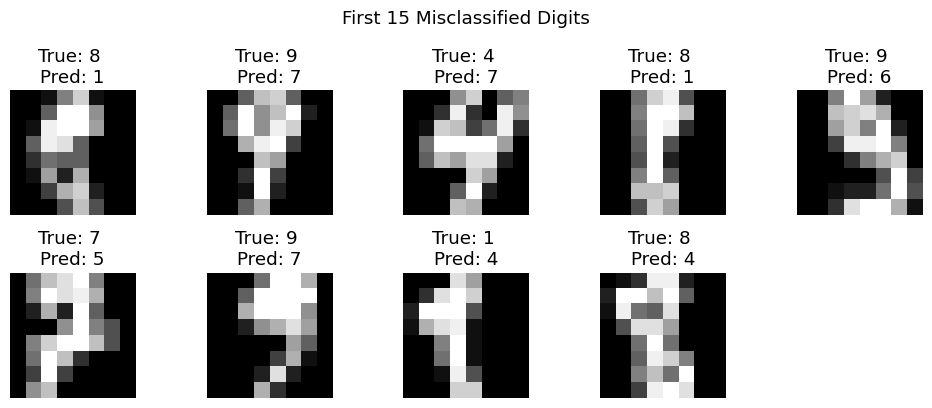


Most misclassified digit: 8
Number of times it was wrong: 3


In [18]:
# ── Your code here ────────────────────────────────────────────────────────


import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from collections import Counter

# 👉 Use your best values from Task 11
best_kernel = 'rbf'
best_C = best_C   # already computed earlier

# Train on full training data
best_model = SVC(kernel=best_kernel, C=best_C, random_state=42)
best_model.fit(X_train_s, y_train)

# Predict on test set
y_pred = best_model.predict(X_test_s)

# Find wrong predictions
wrong = np.where(y_pred != y_test)[0]

print(f'Total mistakes: {len(wrong)}')

# -----------------------------
# 📊 Show first 15 mistakes
# -----------------------------
plt.figure(figsize=(10, 6))

for i, idx in enumerate(wrong[:15]):
    plt.subplot(3, 5, i+1)

    plt.imshow(X_test[idx].reshape(8, 8), cmap='gray')
    plt.title(f'True: {y_test[idx]} \nPred: {y_pred[idx]}')
    plt.axis('off')

plt.suptitle('First 15 Misclassified Digits')
plt.tight_layout()
plt.show()

# -----------------------------
# 📌 Most misclassified digit
# -----------------------------
wrong_true_labels = y_test[wrong]
most_common = Counter(wrong_true_labels).most_common(1)[0]

print(f"\nMost misclassified digit: {most_common[0]}")
print(f"Number of times it was wrong: {most_common[1]}")

**💬 Think About It:**

*Looking at the mistakes — do they make sense? Can you see why the model was confused?*  
*Which digit is hardest to classify correctly?*  
*What could you do to improve the model further?*

<details><summary>💡 Reveal Solution</summary>

```python
best_clf = svm.SVC(kernel='rbf', C=10)   # use your best C from Task 11
best_clf.fit(X_d_tr_s, y_d_tr)
y_pred = best_clf.predict(X_d_te_s)

wrong = np.where(y_pred != y_d_te)[0]
print(f'Total mistakes: {len(wrong)} out of {len(y_d_te)}  ({len(wrong)/len(y_d_te)*100:.1f}% error rate)')

fig, axes = plt.subplots(3, 5, figsize=(12, 7))
for ax, idx in zip(axes.ravel(), wrong[:15]):
    ax.imshow(X_d_te[idx].reshape(8,8), cmap='gray_r')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'True: {y_d_te[idx]}\nPred: {y_pred[idx]}',
                 color='red', fontsize=10, fontweight='bold')

plt.suptitle('SVM Mistakes — Can you see why these were hard?',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Which digit confused most often?
true_wrong = y_d_te[wrong]
from collections import Counter
counts = Counter(true_wrong)
print('\nMost confused digits (true label → how many mistakes):')
for digit, n in sorted(counts.items(), key=lambda x: -x[1]):
    print(f'  Digit {digit}: {n} mistakes')
```
</details>

---
---
# 🏁 PART 4 — Bringing It All Together

---

## ✏️ Task 13 — Best Model for Each Dataset

### Background
You have now practised on all 3 datasets.  
This final task asks you to build the **best model you can** for each dataset, using what you have learned:
- Scale the data
- Try different kernels
- Use cross-validation to choose C
- Only evaluate on the test set once, at the very end

### Steps
For each of the 3 datasets (Breast Cancer, Iris, Digits):
1. Choose the kernel and C you think will work best (based on your earlier tasks)
2. Train a final model with those settings
3. Evaluate on the test set
4. Fill in the comparison table below with your results

Then plot a horizontal bar chart comparing all 3 test accuracies.

| Dataset | Kernel | C | Test Accuracy |
|---|---|---|---|
| Breast Cancer | | | |
| Iris | | | |
| Digits | | | |

In [ ]:
# ── Your code here ────────────────────────────────────────────────────────
# Choose your own kernel and C for each dataset based on what you learned!





<details><summary>💡 Reveal Solution</summary>

```python
configs = [
    ('Breast Cancer', cancer.data, cancer.target, 'linear', 1),
    ('Iris',          iris.data,   iris.target,   'rbf',    1),
    ('Digits',        digits.data, digits.target, 'rbf',   10),
]

results = []
print(f'{"Dataset":>15}  {"Kernel":>8}  {"C":>6}  {"Test Acc":>10}')
print('-' * 48)

for name, X, y, kernel, C in configs:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s  = sc.transform(X_te)
    clf = svm.SVC(kernel=kernel, C=C)
    clf.fit(X_tr_s, y_tr)
    acc = clf.score(X_te_s, y_te)
    results.append((name, acc))
    print(f'{name:>15}  {kernel:>8}  {C:>6}  {acc:>10.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
names, accs = zip(*results)
bars = ax.barh(names, accs, color=['#E63946','#2A9D8F','#457B9D'], edgecolor='k')
ax.set_xlim(0.85, 1.02)
for bar, acc in zip(bars, accs):
    ax.text(acc+0.002, bar.get_y()+bar.get_height()/2,
            f'{acc*100:.1f}%', va='center', fontweight='bold')
ax.set_xlabel('Test Accuracy')
ax.set_title('Best SVM Results Across All 3 Datasets', fontweight='bold')
plt.tight_layout(); plt.show()
```
</details>

---
## 📝 Final Reflection

*There are no right or wrong answers — just think it through and write your answers below.*

---

**Q1 — Support Vectors:**  
In Task 3, you found that only a small % of training points are support vectors.  
What does this tell you about how SVM "learns" compared to other models?

**Q2 — The C parameter:**  
A classmate says: "I always set C=1000 so the model works hard and makes fewer mistakes."  
What would you say to them?

**Q3 — Kernels:**  
In Task 10, you found that even a linear kernel works well on 64-dimensional image data.  
Why do you think a straight-line boundary can work well in very high dimensions?

**Q4 — Scaling:**  
In Task 2, scaling improved accuracy significantly.  
Why do we fit the scaler on training data only, and not on the whole dataset?

**Q5 — Mistakes:**  
Looking at the digit mistakes in Task 12 — they are not random.  
What does this suggest about the types of images that are inherently hard to classify?

**Your answers:**

Q1:SVM doesn’t learn from all data points equally.

👉 It mainly learns from support vectors (the points closest to the boundary).

What this means:
Most data points are ignored
Only “critical” points define the decision boundary
Compared to other models:
Decision Trees → use all data
KNN → depends on all neighbors
SVM → depends on few important points

✅ So SVM is efficient + focused, not influenced by unnecessary data

Q2:Your classmate is wrong (partially) 😄

Setting C = 1000 means:

Model tries to classify every point correctly
Becomes too strict
Problem:
Overfitting happens
Train accuracy ↑ but test accuracy ↓
Better answer:

👉 “High C reduces training errors but hurts generalization.”

✅ Always tune C, don’t fix it blindly

Q3:In 64 dimensions (like digit pixels):

👉 Data becomes easier to separate

Why?
More features = more ways to separate data
Points spread out in space
Classes become more separable
Result:

Even a linear boundary (straight line) can work well

✅ High dimension = natural separation improves

Q4:We only fit scaler on training data to avoid:

👉 Data leakage

If we scale on full dataset:
Test data information leaks into training
Model becomes unrealistically good
Correct approach:
scaler.fit(X_train)
scaler.transform(X_train)
scaler.transform(X_test)

Q5:Mistakes are not random — very important insight.

What it means:

Some digits are inherently similar, e.g.:

3 vs 8
4 vs 9
So:
Even humans can get confused
Model struggles on ambiguous patterns

✅ Hard images = overlapping features between classes

---
## 🗺️ What You Covered

```
🏥 Breast Cancer  (Tasks 1–5)
   Task 1  →  Explore: class balance and feature ranges
   Task 2  →  Prove why scaling matters (with numbers!)
   Task 3  →  Prove that only support vectors decide the boundary
   Task 4  →  See how C controls underfitting vs overfitting
   Task 5  →  Confusion matrix: not all mistakes are equal

🌸 Iris Flowers  (Tasks 6–8)
   Task 6  →  Visualise the decision boundary in 2D
   Task 7  →  Watch the boundary change as C changes
   Task 8  →  Compare linear, RBF, and polynomial kernels

✍️  Digits  (Tasks 9–12)
   Task 9  →  Always look at your data — display the images
   Task 10 →  Which kernel works best on 64-dimensional data?
   Task 11 →  Tune C using cross-validation
   Task 12 →  Inspect mistakes to understand model limits

🏁 Final  (Task 13)
   Task 13 →  Build best model per dataset, compare all three
```

---
*🎓 Well done! You have built intuition for SVM on three real-world problems.*